In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim


# здесь адаптация! оригинал по ссылке: https://www.kaggle.com/code/manaswinigatika/hyperspectral-imaging-attention

In [2]:
def extract_patches(data, gt, patch_size):
    margin = patch_size // 2
    patches, labels = [], []
    data_pca = pca.fit_transform(data.reshape(-1, data.shape[2])).reshape(h, w, pca_bands)
    for i in range(margin, h - margin):
        for j in range(margin, w - margin):
            label = gt[i, j]
            if label > 0:
                cube = data_pca[i-margin:i+margin+1, j-margin:j+margin+1, :]
                patches.append(cube)
                labels.append(label - 1)
    return np.array(patches), np.array(labels)

class D2BERT(nn.Module):
    def __init__(self, seq_len, feature_dim, d_model, num_classes, num_layers, num_heads):
        super().__init__()
        self.embedding = nn.Linear(feature_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)
    def forward(self, x):
        x = self.embedding(x) + self.pos_embed  # (batch, seq, d_model)
        x = x.permute(1, 0, 2)  # (seq, batch, d_model)
        x = self.transformer(x)
        x = x.mean(dim=0)  # (batch, d_model)
        return self.classifier(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [3]:
data = np.load('indianpinearray.npy')
gt = np.load('IPgt.npy')

h, w, bands = data.shape

patch_size = 3
pca_bands = 30
margin = patch_size // 2
test_size = 0.9

epochs = 100
batch_size = 64

num_layers = 2
num_heads = 1

pca = PCA(n_components=pca_bands)

patches, labels = extract_patches(data, gt, patch_size=patch_size)
patches_flat = patches.reshape(patches.shape[0], -1, patches.shape[-1])
num_classes = len(np.unique(labels))

C:\Users\Finzz\AppData\Local\Temp\ipykernel_10276\3088223473.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Number of parameters in the model: 565904
Epoch 10/100, Training Loss: 0.6862, Training Accuracy: 0.7758, Validation Loss: 0.7994, Validation Accuracy: 0.7175
Epoch 20/100, Training Loss: 0.3521, Training Accuracy: 0.8889, Validation Loss: 0.5401, Validation Accuracy: 0.8119
Epoch 30/100, Training Loss: 0.1740, Training Accuracy: 0.9489, Validation Loss: 0.4830, Validation Accuracy: 0.8620
Epoch 40/100, Training Loss: 0.1552, Training Accuracy: 0.9508, Validation Loss: 0.4707, Validation Accuracy: 0.8643
Epoch 50/100, Training Loss: 0.1948, Training Accuracy: 0.9430, Validation Loss: 0.5110, Validation Accuracy: 0.8523
Epoch 60/100, Training Loss: 0.1601, Training Accuracy: 0.9479, Validation Loss: 0.5844, Validation Accuracy: 0.8540
Epoch 70/100, Training Loss: 0.1524, Training Accuracy: 0.9528, Validation Loss: 0.5815, Validation Accuracy: 0.8522
Epoch 80/100, Training Loss: 0.0393, Training Accuracy: 0.9853, Validation Loss: 0.5568, Validation Accuracy: 0.8597
Epoch 90/100, Training

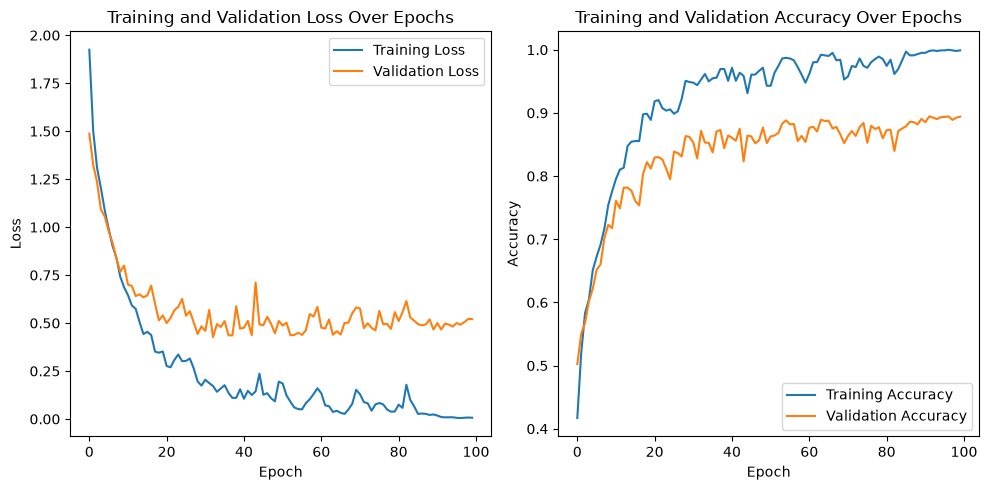

Test Accuracy: 89.40%


In [4]:
X_train, X_test, y_train, y_test = train_test_split(patches_flat, labels, test_size=test_size, random_state=42, stratify=labels)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

seq_len = patches_flat.shape[1]
feature_dim = patches_flat.shape[2]

model = D2BERT(seq_len=seq_len, feature_dim=feature_dim, d_model=64, num_classes=num_classes, num_layers=num_layers, num_heads=num_heads)
num_params = count_parameters(model)
print(f"Number of parameters in the model: {num_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    epoch_train_loss = 0.0
    correct_train = 0

    for i in range(0, X_train.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct_train += (preds == batch_y).sum().item()

    avg_train_loss = epoch_train_loss / (X_train.size(0) // batch_size)
    train_losses.append(avg_train_loss)
    train_accuracy = correct_train / X_train.size(0)
    train_accuracies.append(train_accuracy)

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
        val_losses.append(val_loss.item())
        
        val_preds = val_outputs.argmax(dim=1)
        correct_val = (val_preds == y_test).sum().item()
        val_accuracy = correct_val / X_test.size(0)
        val_accuracies.append(val_accuracy)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_accuracy:.4f}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc = (preds == y_test).float().mean().item()
print(f"Test Accuracy: {acc * 100:.2f}%")

pred_map = np.zeros((h, w), dtype=int)

for i in range(margin, h - margin):
    for j in range(margin, w - margin):
        # Пропускаем пиксели фона при необходимости
        if gt[i, j] == 0:
            continue
        cube = data[i-margin:i+margin+1, j-margin:j+margin+1, :]
        cube_flat = cube.reshape(-1, bands)
        cube_pca = pca.transform(cube_flat)
        patch = cube_pca.reshape(patch_size * patch_size, -1)
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0)
        model.eval()
        with torch.no_grad():
            output = model(patch_tensor)
            pred_class = output.argmax(dim=1).item()
        pred_map[i, j] = pred_class + 1  # Добавляем 1, если ваши классы начинаются с 1

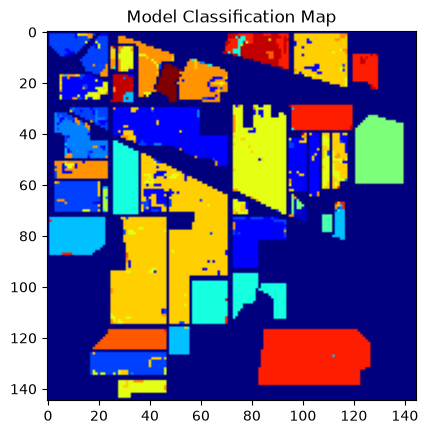

In [5]:
plt.imshow(pred_map, cmap='jet')
plt.title('Model Classification Map')
plt.show()